d:\Program Files\Python312\Lib\site-packages\jieba\_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Building prefix dict from the default dictionary ...


通知人
教学运行    32.6
实践科     23.6
质量办     12.4
计划科      9.6
教研教改     8.2
综合科      7.8
教材中心     4.6
未知       1.0
电教中心     0.2
Name: proportion, dtype: float64
日期
2023/6/19    2
2023/6/15    1
2023/6/14    1
2023/6/13    1
2023/6/12    1
            ..
2025/9/5     3
2025/9/4     1
2025/9/2     1
2025/8/29    1
2025/8/20    1
Name: count, Length: 284, dtype: int64


Dumping model to file cache C:\Users\Lst12\AppData\Local\Temp\jieba.cache
Loading model cost 0.431 seconds.
Prefix dict has been built successfully.


<BarContainer object of 17 artists>

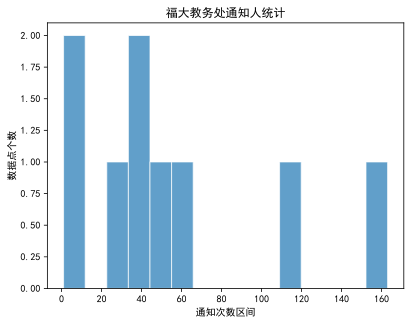

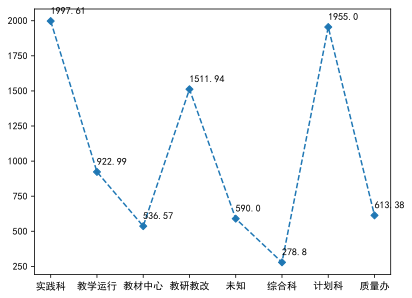

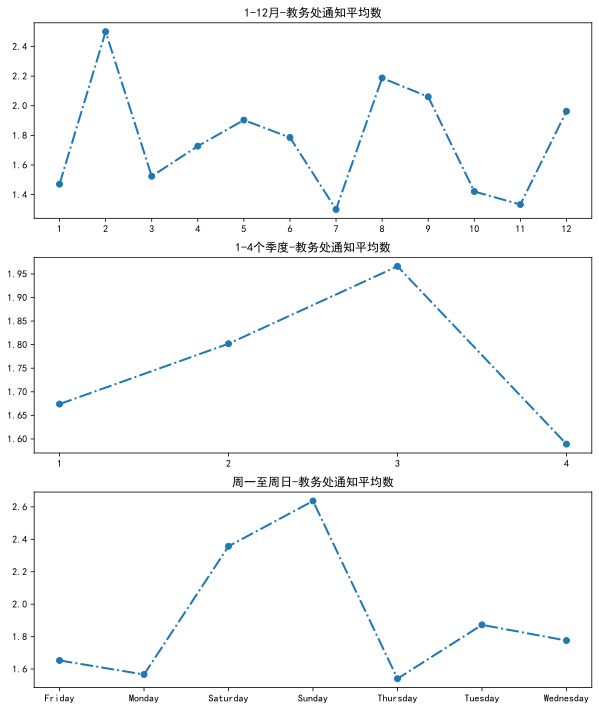

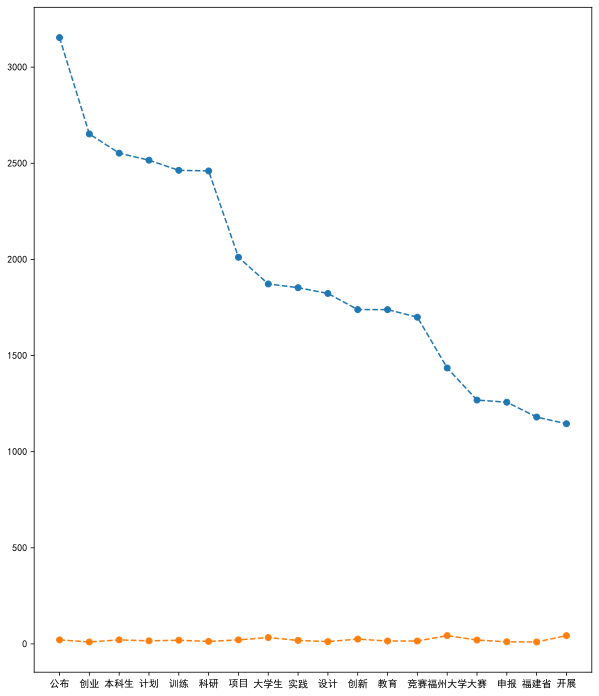

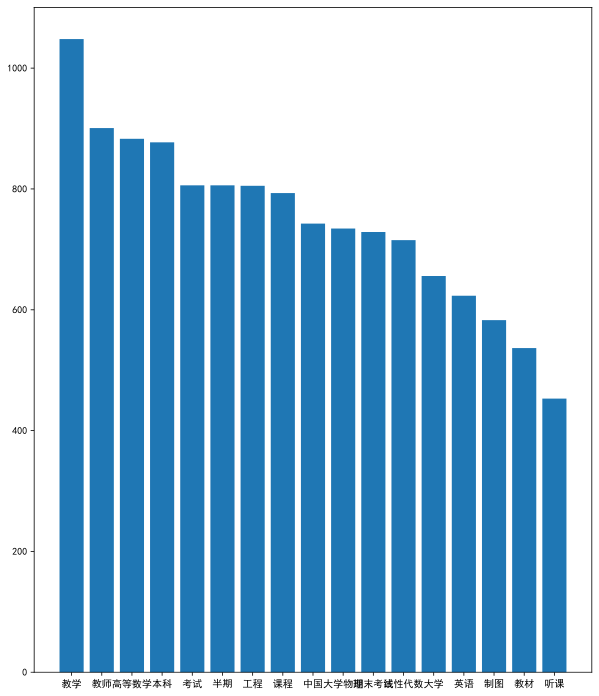

In [ ]:

import matplotlib.pyplot as plt
# %matplotlib inline 
from matplotlib_inline import backend_inline   
backend_inline.set_matplotlib_formats('svg') #显示矢量图
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']   #设置中文字体正常显示

import numpy as np
import pandas as pd
import jieba
import re

"""通知人与通知次数关系"""
dic = pd.read_csv(r"c:\Users\Lst12\Desktop\福大教务处通知.csv",index_col=0)

notifier_count = dic['通知人'].value_counts()  #输出series,带索引值
notifier_ratio = dic['通知人'].value_counts(normalize=True,sort=True,ascending=False,dropna=False,)*100
# print(dic['通知人'])
# print(notifier_count)
# print(notifier_ratio)
#valuecounts函数在notebook里面功能不止是统计value有哪些，还会统计每个value出现几次
#normalize参数规定是否以比例形式输出，*100即百分比
#sort参数，是否从大到小排序,dropna参数,是否包含缺失值
#ascending参数规定是否为升序即从小到大排，False就是从大到小
#bins参数，分箱统计，当为纯数字数据才用，统计不同数字段的个数

k = ['电教中心','未知','教材中心','综合科','教研教改','计划科','质量办','实践科','教学运行']
notifier_summary = pd.DataFrame({'通知次数':notifier_count,'权重':notifier_ratio},index=k)
#print(notifier_summary)  #此处可以直接用series对象创建dataframe是因为两个都是valuecounts的结果，索引值是一样的，可以自动对齐
"""可视化柱形图"""
Fig1 = plt.figure()
plt.hist(notifier_summary['通知次数'],bins=15,alpha=0.7,edgecolor='#FFFFFF')  #y轴表示有几个这个数据范围内的元素，x轴表示通知次数范围
plt.title('福大教务处通知人统计')
plt.xlabel('通知次数区间')
plt.ylabel('数据点个数')

"""通知人与下载量的关系"""
notifier = dic.dropna(subset=['下载量1'])['通知人'].values  #subset参数规定，当下载量1为NAN时才清除
accessory_download_times = dic['下载量1'].dropna().values  #必须要求同形对象，并且都为列表形式，才能用dataframe
accessory_factor = pd.DataFrame({'下载量':accessory_download_times,'通知人':notifier})
# print(accessory_factor) #取下载量1，和通知人，找其关系
link = accessory_factor.pivot_table('下载量',columns='通知人').round(2) #四舍五入两位
# print(link)  #link为每个通知人对应的下载量平均数

"""可视化折线图"""
settle_link = link.values.reshape(8) #从二维转为向量，方便plot
k1 = np.array(['实践科','教学运行','教材中心','教研教改','未知','综合科','计划科','质量办'])

Fig2 = plt.figure()
plt.plot(k1,settle_link,linestyle='--',marker='D',markersize=5)

for (x,y) in zip(k1,settle_link):  #遍历xy数组，在图表中标记上具体数据，更好对比
    plt.annotate(y,xy=(x,y),xytext=(x,y+50))  #annotate方法进行标记文本，y是标记文本内容，xy为标记点坐标，xytext是文本的坐标


"""获取日期与通知次数的关系"""
date_counts = dic['日期'].value_counts(sort=False)
print(date_counts)  #筛选日期，看看哪个日期出现次数最多
# date_counts.to_csv(r'C:\Users\Lst12\Desktop\日期完整数据.csv', encoding='utf-8-sig')  #tocsv保存文件查看全部
date_summary = pd.DataFrame({'日期':date_counts.index,'通知次数':date_counts.values},index=np.arange(0,284))
#print(date_summary)

"""缩小精度,获取月份,季度,星期与平均通知次数的关系"""
date_summary['日期'] = pd.to_datetime(date_summary['日期'])  #动用pd的dt函数，首先用to_datetime方法把时间格式规范
date_summary['月份'] = date_summary['日期'].dt.month #dt函数获得月份，季度，星期，生成列表
date_summary['季度'] = date_summary['日期'].dt.quarter #把新一列数据添加进列表
date_summary['星期'] = date_summary['日期'].dt.day_name()
# print(date_summary)
months = date_summary.groupby(['月份'])['通知次数'].agg(['mean','max'])
quaters = date_summary.groupby(['季度'])['通知次数'].agg(['mean','max'])
days = date_summary.groupby(['星期'])['通知次数'].agg(['mean','max'])
# print(days)
# print(quaters)
# print(months)

"""可视化折线图"""
Fig3,ax3 = plt.subplots(3,1,figsize=(10,12))
ax3[0].set_title('1-12月-教务处通知平均数')
ax3[0].plot(months.index,months['mean'].values,linestyle='-.',linewidth='2',marker='o')
ax3[0].set_xticks(np.arange(1,13)) #设置xy轴精度，tick

ax3[1].set_title('1-4个季度-教务处通知平均数')
ax3[1].plot(quaters.index,quaters['mean'].values,linestyle='-.',linewidth='2',marker='o')
ax3[1].set_xticks(np.arange(1,5,1))

ax3[2].set_title('周一至周日-教务处通知平均数')
ax3[2].plot(days.index,days['mean'].values,linestyle='-.',linewidth='2',marker='o')

"""判断什么关键词出现对下载量的影响"""
heads = dic.dropna(subset=['下载量1'])['标题'].values
head_summary = pd.DataFrame({'标题':heads,'下载量':accessory_download_times})
key_words = []
useless_words = ['关于','第二','第一','通知','工作','安排','学年','学期','三四','第一周','年度','组织','举办','第二十八','第三十一','二十九','第三十','第二十四届','级数','第二十九','第二十七','二十八期','对届','做好','学年度','第十六届','第二十五届','第八届','推荐','以上','第十八届','中期','参加','进行','参与','中下','第十七届','学生','社杯']

"""提取列表各个文本里的各个关键词，并储存至字典"""
for head,downloads in zip(heads,accessory_download_times):
    cleared_head = re.sub(r'[^\u4e00-\u9fa5]','',head)  #清除非中文的标题部分，返回的仍是完整字符串，如果用findall会分成好多个''就不能用jieba了
    split_head = jieba.lcut(cleared_head)   #jieba中文分析工具，自动搜索常用词进行匹配，分词
    for key_word in split_head:
        if key_word not in useless_words and len(key_word)>1:  #排除无关词和长度为一的词
            key_words.append({'关键词':key_word,'下载量':downloads})

"""创建series对象"""
key_words_analysis = pd.DataFrame(key_words)  #包含多个同key字典的列表也能作为dataframe的参数
counts = key_words_analysis.value_counts('关键词')   #提取关键词的所有value，统计出现次数

integrated = key_words_analysis.groupby(['关键词'])['下载量'].agg(['mean']).round(2)  #以关键词分组对下载量进行求均值，并四舍五入两位
integrated['出现次数'] = counts  #把出现次数列名添加进前面创建的series对象里
ordered_integrated = integrated[integrated['出现次数'] >= 10].sort_values(by=['mean'],ascending=[False])  #用布尔索引提取出现次数大于15的关键词，sortvalue根据列名升序降序排序values
# ordered_integrated.to_csv(r'C:\Users\Lst12\Desktop\关键词完整数据.csv', encoding='utf-8-sig')

"""可视化折线图和柱状图"""
Fig4 = plt.figure(figsize=(10,12))
plt.plot(ordered_integrated.iloc[:18].index,ordered_integrated.iloc[:18].values,linestyle='--',marker='o')

Fig5 = plt.figure(figsize=(10,12))
plt.bar(ordered_integrated.iloc[18:].index,ordered_integrated.iloc[18:]['mean'].values)  #bar条形图优于柱形图的一点就是可以输入两个数组







